[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/14_vector_calculus_field_theorems/first_principles.ipynb)

# Module 14 — Vector Calculus and Field Theorems

Line integrals, surface integrals, the three differential operators, and the four theorems
that tie a field's interior derivative to its behaviour on the boundary.

---

## 1. Why This Module Exists

Single-variable calculus closes with one identity, the Fundamental Theorem of Calculus:

$$
\int_a^b f'(x)\,\mathrm{d}x = f(b) - f(a).
$$

The interval $[a,b]$ has a two-point boundary $\{a, b\}$, and the theorem says that
integrating the *derivative* over the interval reproduces the *original function* evaluated
on that boundary. Everything in this module is that sentence, repeated in higher dimension.

Once the domain of integration is a curve, a surface, or a solid, the "boundary" becomes a
geometric object in its own right and the "derivative" splits into three distinct operators —
gradient, curl and divergence. Module 11 built the gradient and Module 13 built the iterated
integral; what is still missing is the bookkeeping that connects them. Concretely, three
questions cannot be answered with the tools of Modules 11 and 13 alone:

- A force field pushes a particle around a closed loop. Is the net work zero? For some fields
  it always is, for others never, and the deciding property turns out to be topological, not
  analytic.
- A fluid occupies a region $V$. How much mass leaves through $\partial V$ per unit time, and
  can that number be recovered from the velocity field's behaviour *inside* $V$, without ever
  parameterizing the boundary surface?
- A neural-ODE flow transports a probability density. How does $\log p$ change along a
  trajectory?

Each answer is one line of one of the theorems proved in Section 5. The same theorems are the
integral-to-differential bridge behind Maxwell's equations, the finite volume method, and the
instantaneous change-of-variables formula used in continuous normalizing flows.

---

## 2. Intuition

Fix a point $\mathbf{x}_0$ and imagine a very small ball of dye released into a flow
$\mathbf{F}$. Two things can happen to the dye, and they are independent of each other.

**It can grow or shrink.** If more dye leaves the small ball than enters it, the flow is
*creating* volume at $\mathbf{x}_0$. Measure that as flux out of the ball's surface divided
by the ball's volume; the limit as the ball shrinks is the **divergence**.

**It can spin.** Put a tiny paddle wheel at $\mathbf{x}_0$ with its axis along $\mathbf{n}$.
If the flow along one side of the wheel is stronger than along the other, the wheel turns.
Measure that as circulation around the wheel's rim divided by the rim's enclosed area; the
limit is the component of the **curl** along $\mathbf{n}$.

These are *local* numbers, defined at a point. The field theorems say they add up
globally in the only way they possibly could: cut a region into many small cells, and every
internal face is shared by exactly two cells with opposite orientation, so the internal
contributions cancel in pairs. Only the outermost faces survive. That single cancellation
picture — internal boundaries cancel, the outer boundary remains — is the whole content of
Green's Theorem, Stokes' Theorem, and the Divergence Theorem. The proofs in Section 5 make
the cancellation exact rather than pictorial.

The figure below draws three planar fields chosen so that divergence and curl are separated:
a radial source with $\nabla \cdot \mathbf{F} = 2$ and zero curl, a rigid rotation with zero
divergence and curl $2\mathbf{k}$, and a shear whose streamlines are perfectly straight yet
whose curl is nonzero — the standard warning that "straight streamlines" and "no rotation"
are different statements.

Setup: the module preamble. Everything below draws randomness only from `rng`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import integrate
from numpy.polynomial.legendre import leggauss

The next cell draws the Section 2 figure: three planar fields whose divergence and curl are
computed by hand in the panel titles, so the picture and the formulas can be checked against
each other.

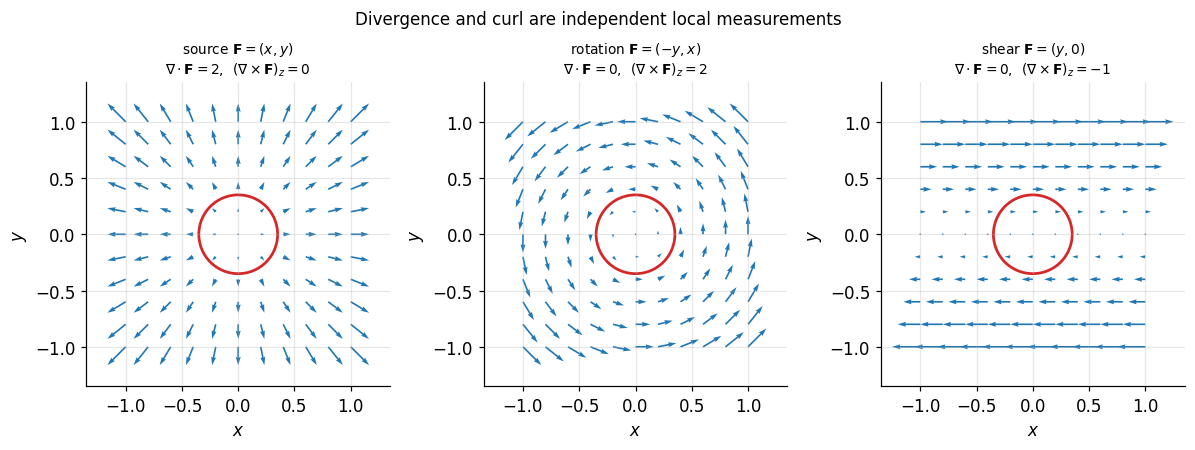

In [2]:
grid = np.linspace(-1.0, 1.0, 11)
X, Y = np.meshgrid(grid, grid)

fields = [
    (X, Y, r"source $\mathbf{F}=(x,y)$", r"$\nabla\cdot\mathbf{F}=2$,  $(\nabla\times\mathbf{F})_z=0$"),
    (-Y, X, r"rotation $\mathbf{F}=(-y,x)$", r"$\nabla\cdot\mathbf{F}=0$,  $(\nabla\times\mathbf{F})_z=2$"),
    (Y, np.zeros_like(X), r"shear $\mathbf{F}=(y,0)$", r"$\nabla\cdot\mathbf{F}=0$,  $(\nabla\times\mathbf{F})_z=-1$"),
]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
for ax, (U, V, name, ops) in zip(axes, fields):
    ax.quiver(X, Y, U, V, color="#1f77b4", angles="xy")
    circ = plt.Circle((0.0, 0.0), 0.35, fill=False, color="#d62728", lw=1.8)
    ax.add_patch(circ)
    ax.set_title(f"{name}\n{ops}", fontsize=9)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
fig.suptitle("Divergence and curl are independent local measurements", fontsize=11)
fig.tight_layout()
plt.show()

The red circle is the "small ball of dye" in each panel. In the source field the arrows cross
it outward everywhere, so flux out is positive and divergence is positive. In the rotation
field every arrow is tangent to the circle, so nothing crosses it — zero divergence — while
the circulation around it is maximal. The shear panel is the instructive one: no arrow points
off the horizontal, yet the arrows above the circle are longer than those below, so a paddle
wheel would turn clockwise, which is exactly $(\nabla\times\mathbf{F})_z = -1 \lt 0$.

---

## 3. Definitions

### Definition 3.1 (Vector field)
Let $U \subseteq \mathbb{R}^n$ be open. A **vector field** on $U$ is a map
$\mathbf{F}: U \to \mathbb{R}^n$. In $\mathbb{R}^3$ we write

$$
\mathbf{F}(x, y, z) = P(x, y, z)\mathbf{i} + Q(x, y, z)\mathbf{j} + R(x, y, z)\mathbf{k},
$$

with scalar components $P, Q, R: U \to \mathbb{R}$. The field is of class $C^k$ when every
component is $k$ times continuously differentiable.

### Definition 3.2 (Scalar line integral)
Let $C \subset \mathbb{R}^n$ be a smooth curve parameterized by $\mathbf{r}: [a,b] \to
\mathbb{R}^n$ with $\mathbf{r}'(t) \neq \mathbf{0}$. For continuous $f$,

$$
\int_C f\,\mathrm{d}s := \int_a^b f(\mathbf{r}(t))\,\lVert \mathbf{r}'(t) \rVert\,\mathrm{d}t ,
$$

with arc-length element $\mathrm{d}s = \lVert \mathbf{r}'(t) \rVert\,\mathrm{d}t$. The value
is independent of the parameterization and of the direction of traversal.

### Definition 3.3 (Vector line integral, work, circulation)
For an oriented smooth curve $C$ with parameterization $\mathbf{r}$ on $[a,b]$,

$$
\int_C \mathbf{F} \cdot \mathrm{d}\mathbf{r} := \int_a^b \mathbf{F}(\mathbf{r}(t)) \cdot \mathbf{r}'(t)\,\mathrm{d}t = \int_C \mathbf{F} \cdot \mathbf{T}\,\mathrm{d}s ,
\qquad \mathbf{T} = \frac{\mathbf{r}'}{\lVert \mathbf{r}' \rVert}.
$$

Reversing the orientation flips the sign. When $\mathbf{r}(a) = \mathbf{r}(b)$ the curve is
closed, the integral is written $\oint_C \mathbf{F} \cdot \mathrm{d}\mathbf{r}$, and it is
called the **circulation** of $\mathbf{F}$ around $C$.

### Definition 3.4 (Conservative field, scalar potential)
$\mathbf{F}: U \to \mathbb{R}^n$ is **conservative** on $U$ if there is a $C^1$ function
$f: U \to \mathbb{R}$, the **scalar potential**, with $\mathbf{F} = \nabla f$ on $U$. In
physics one writes instead $\mathbf{F} = -\nabla V$ with $V$ the potential energy; the sign
is a convention, not a mathematical difference.

### Definition 3.5 (Surface integral and flux)
Let $S \subset \mathbb{R}^3$ be a smooth parametric surface $\mathbf{r}(u,v)$, $(u,v) \in D
\subset \mathbb{R}^2$, with normal element

$$
\mathbf{N}(u,v) := \frac{\partial \mathbf{r}}{\partial u} \times \frac{\partial \mathbf{r}}{\partial v} \neq \mathbf{0}.
$$

Then $\mathrm{d}S := \lVert \mathbf{N} \rVert\,\mathrm{d}u\,\mathrm{d}v$, the scalar surface
integral is $\iint_S f\,\mathrm{d}S = \iint_D f(\mathbf{r})\lVert \mathbf{N} \rVert\,
\mathrm{d}u\,\mathrm{d}v$, and with unit normal $\mathbf{n} = \mathbf{N}/\lVert \mathbf{N}
\rVert$ the **flux** of $\mathbf{F}$ through the oriented surface $S$ is

$$
\iint_S \mathbf{F} \cdot \mathbf{n}\,\mathrm{d}S = \iint_D \mathbf{F}(\mathbf{r}(u,v)) \cdot \mathbf{N}(u,v)\,\mathrm{d}u\,\mathrm{d}v .
$$

Flux changes sign when $\mathbf{n}$ is replaced by $-\mathbf{n}$; it is defined only for
**orientable** surfaces, where a continuous unit normal exists globally.

### Definition 3.6 (Gradient, divergence, curl)
With $\nabla = \mathbf{i}\,\partial_x + \mathbf{j}\,\partial_y + \mathbf{k}\,\partial_z$ and
$\mathbf{F} = (P,Q,R)$ of class $C^1$:

$$
\nabla f = (f_x, f_y, f_z), \qquad
\nabla \cdot \mathbf{F} = P_x + Q_y + R_z, \qquad
\nabla \times \mathbf{F} = (R_y - Q_z,\; P_z - R_x,\; Q_x - P_y).
$$

The last two have coordinate-free descriptions, which is what makes them geometric rather
than a bookkeeping accident:

$$
(\nabla \cdot \mathbf{F})(\mathbf{x}_0) = \lim_{\operatorname{Vol}(V) \to 0} \frac{1}{\operatorname{Vol}(V)} \oiint_{\partial V} \mathbf{F} \cdot \mathbf{n}\,\mathrm{d}S ,
$$

$$
(\nabla \times \mathbf{F})(\mathbf{x}_0) \cdot \mathbf{n} = \lim_{\operatorname{Area}(S) \to 0} \frac{1}{\operatorname{Area}(S)} \oint_{\partial S} \mathbf{F} \cdot \mathrm{d}\mathbf{r} ,
$$

the limits being taken over regions shrinking regularly to $\mathbf{x}_0$, with $S$ a small
disc through $\mathbf{x}_0$ normal to $\mathbf{n}$. Divergence is flux per unit volume;
the curl component along $\mathbf{n}$ is circulation per unit area in the plane $\perp
\mathbf{n}$.

### Definition 3.7 (Green-admissible region, simple connectivity)
A compact region $D \subset \mathbb{R}^2$ is **Type I** if
$D = \{(x,y) : a \le x \le b,\; g_1(x) \le y \le g_2(x)\}$ with $g_1 \le g_2$ piecewise $C^1$,
and **Type II** if $D = \{(x,y) : c \le y \le d,\; h_1(y) \le x \le h_2(y)\}$ likewise. It is
**Green-admissible** if it is both, or is a finite union of such pieces glued along shared
edges. An open connected $U$ is **simply connected** if every loop in $U$ is
null-homotopic in $U$, i.e. can be contracted to a point without leaving $U$.

---

## 4. Main Results

### Theorem 4.1 (Fundamental Theorem of Line Integrals)
Let $U \subseteq \mathbb{R}^n$ be open, $f : U \to \mathbb{R}$ of class $C^1$, and $C \subset
U$ a piecewise smooth curve from $A = \mathbf{r}(a)$ to $B = \mathbf{r}(b)$. Then

$$
\int_C \nabla f \cdot \mathrm{d}\mathbf{r} = f(B) - f(A).
$$

*Hypotheses.* $f \in C^1$ makes $t \mapsto f(\mathbf{r}(t))$ differentiable with the chain
rule available; *piecewise* smoothness of $C$ lets the FTC be applied on each smooth piece
and the endpoint terms telescope; $C \subset U$ is needed because $\nabla f$ exists only on
$U$.

### Theorem 4.2 (Green's Theorem)
Let $D \subset \mathbb{R}^2$ be Green-admissible with boundary $\partial D$ a finite union of
simple closed piecewise-$C^1$ curves, positively oriented (traversed with $D$ on the left).
Let $P, Q$ be $C^1$ on an open set containing $D$. Then

$$
\oint_{\partial D} \left( P\,\mathrm{d}x + Q\,\mathrm{d}y \right) = \iint_D \left( \frac{\partial Q}{\partial x} - \frac{\partial P}{\partial y} \right) \mathrm{d}A ,
$$

and equivalently, for $\mathbf{F} = (P, Q)$ with outward unit normal $\mathbf{n}$ on
$\partial D$,

$$
\oint_{\partial D} \mathbf{F} \cdot \mathbf{n}\,\mathrm{d}s = \iint_D (\nabla \cdot \mathbf{F})\,\mathrm{d}A .
$$

*Hypotheses.* $C^1$ on a neighbourhood of $D$ (not merely on the interior) is what allows the
inner FTC step at the boundary values $g_1, g_2$; Example 7.2 below breaks the conclusion by
puncturing $D$ at one point. Green-admissibility is what makes Fubini plus the FTC available
in each coordinate direction. Positive orientation fixes the sign; reversing it negates the
left side.

### Theorem 4.3 (Stokes' Theorem)
Let $S \subset \mathbb{R}^3$ be an oriented piecewise smooth surface with unit normal
$\mathbf{n}$, whose boundary $\partial S$ is a simple closed piecewise-$C^1$ curve oriented
compatibly by the right-hand rule. Let $\mathbf{F}$ be $C^1$ on an open set containing $S$.
Then

$$
\oint_{\partial S} \mathbf{F} \cdot \mathrm{d}\mathbf{r} = \iint_S (\nabla \times \mathbf{F}) \cdot \mathbf{n}\,\mathrm{d}S .
$$

*Hypotheses.* Orientability is needed for $\mathbf{n}$ to exist globally (a Möbius band has
no such $\mathbf{n}$ and the right-hand side is meaningless). $\mathbf{F} \in C^1$ makes
$\nabla \times \mathbf{F}$ continuous, hence integrable. The right-hand-rule compatibility
fixes the relative sign of the two sides. Note the right side does not mention $S$ beyond its
boundary in any essential way — see Theorem 4.6.

### Theorem 4.4 (Gauss's Divergence Theorem)
Let $V \subset \mathbb{R}^3$ be a compact region that is a finite union of regions each of
which is simultaneously of Type I, II and III (that is, expressible as the region between two
graphs over each of the three coordinate planes), with boundary $\partial V$ piecewise smooth
and oriented by the outward unit normal $\mathbf{n}$. Let $\mathbf{F}$ be $C^1$ on an open set
containing $V$. Then

$$
\oiint_{\partial V} \mathbf{F} \cdot \mathbf{n}\,\mathrm{d}S = \iiint_V (\nabla \cdot \mathbf{F})\,\mathrm{d}V .
$$

*Hypotheses.* The Type I/II/III description is what lets Fubini reduce each component
identity to a one-dimensional FTC. Compactness plus $C^1$ on a neighbourhood makes both
integrals finite. Outward orientation fixes the sign. If $\mathbf{F}$ fails to be $C^1$ at a
single interior point the conclusion can fail badly — the inverse-square field has zero
divergence off the origin yet flux $4\pi$ through any enclosing sphere.

### Theorem 4.5 (Path-independence equivalence)
Let $\mathbf{F}$ be continuous on an open connected $U \subseteq \mathbb{R}^n$. The following
are equivalent.

1. $\mathbf{F}$ is conservative on $U$ (Definition 3.4).
2. $\int_{C_1} \mathbf{F} \cdot \mathrm{d}\mathbf{r} = \int_{C_2} \mathbf{F} \cdot
   \mathrm{d}\mathbf{r}$ for any two piecewise smooth curves in $U$ with the same endpoints.
3. $\oint_C \mathbf{F} \cdot \mathrm{d}\mathbf{r} = 0$ for every piecewise smooth closed
   curve $C \subset U$.

Moreover, if $\mathbf{F}$ is $C^1$ then (1) implies $\nabla \times \mathbf{F} = \mathbf{0}$;
the converse holds **if $U$ is simply connected** and fails otherwise.

*Hypotheses.* Connectedness of $U$ is needed to build a potential by integrating from one
base point; on a disconnected $U$ one gets a potential per component, with independent
constants. Simple connectivity is exactly what upgrades the local statement
$\nabla \times \mathbf{F} = \mathbf{0}$ to the global statement $\mathbf{F} = \nabla f$.

### Theorem 4.6 (Second-derivative identities and their corollary)
For $f$ of class $C^2$ and $\mathbf{F}$ of class $C^2$ on an open set,

$$
\nabla \times (\nabla f) = \mathbf{0}, \qquad \nabla \cdot (\nabla \times \mathbf{F}) = 0 .
$$

*Corollary.* If $\nabla \cdot \mathbf{F} = 0$ and $S_1, S_2$ are oriented surfaces with the
same boundary curve, bounding a region to which Theorem 4.4 applies, then the flux of
$\mathbf{F}$ through them is equal: flux of a divergence-free field depends only on
$\partial S$.

*Hypotheses.* $C^2$ is what licenses Clairaut's theorem on equality of mixed partials; both
identities are false for fields whose second partials exist but are discontinuous.

### Theorem 4.7 (Helmholtz–Hodge decomposition on $\mathbb{R}^3$)
Let $\mathbf{F}$ be a $C^2$ vector field on $\mathbb{R}^3$ with $\mathbf{F}$, $\nabla \cdot
\mathbf{F}$ and $\nabla \times \mathbf{F}$ decaying faster than $\lVert \mathbf{r}
\rVert^{-2}$ at infinity. Then there exist a scalar field $\phi$ and a vector field
$\mathbf{A}$ with $\nabla \cdot \mathbf{A} = 0$ such that

$$
\mathbf{F} = -\nabla \phi + \nabla \times \mathbf{A} ,
$$

and the two summands are unique.

*Hypotheses.* The decay hypothesis is not cosmetic: it makes the Newtonian convolutions
converge, and it is the *only* reason uniqueness holds — for $\mathbf{F}$ constant one may add
any harmonic function's gradient to the first term and subtract it from the second.

### Theorem 4.8 (Generalized Stokes' Theorem — cited, not proved here)
Let $\Omega$ be a compact oriented smooth $k$-manifold with boundary $\partial\Omega$ carrying
the induced orientation, and let $\omega$ be a $C^1$ $(k-1)$-form on $\Omega$. Then

$$
\int_{\partial \Omega} \omega = \int_{\Omega} \mathrm{d}\omega .
$$

Theorems 4.1–4.4 are the cases $k = 1, 2, 2, 3$ in $\mathbb{R}^3$ under the correspondence
$f \leftrightarrow$ $0$-form, $\mathbf{F} \leftrightarrow$ work $1$-form
$P\,\mathrm{d}x + Q\,\mathrm{d}y + R\,\mathrm{d}z$, $\mathbf{F} \leftrightarrow$ flux $2$-form
$P\,\mathrm{d}y \wedge \mathrm{d}z + Q\,\mathrm{d}z \wedge \mathrm{d}x + R\,\mathrm{d}x \wedge
\mathrm{d}y$. Proving it requires the wedge product, the exterior derivative on general
$k$-forms, pullbacks and partitions of unity, none of which are developed here; the full
proof is Spivak, *Calculus on Manifolds*, Theorem 5-5 (pp. 124–125), with the machinery in
Chapters 4–5. Section 5 instead proves the three classical cases in full, from Fubini and the
one-dimensional FTC only.

---

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)
By Definition 3.3 and the hypothesis $\mathbf{F} = \nabla f$,

$$
\int_C \nabla f \cdot \mathrm{d}\mathbf{r} = \int_a^b \nabla f(\mathbf{r}(t)) \cdot \mathbf{r}'(t)\,\mathrm{d}t .
$$

Because $f \in C^1$ and $\mathbf{r}$ is differentiable, the multivariable chain rule gives
$\frac{\mathrm{d}}{\mathrm{d}t} f(\mathbf{r}(t)) = \nabla f(\mathbf{r}(t)) \cdot
\mathbf{r}'(t)$ at every $t$ where $\mathbf{r}$ is smooth. Hence the integrand is an exact
derivative and the one-dimensional FTC applies on each smooth piece:

$$
\int_a^b \frac{\mathrm{d}}{\mathrm{d}t}\big[f(\mathbf{r}(t))\big]\,\mathrm{d}t = f(\mathbf{r}(b)) - f(\mathbf{r}(a)).
$$

Summing over the finitely many pieces, the interior endpoint values cancel telescopically:

$$
\boxed{\int_C \nabla f \cdot \mathrm{d}\mathbf{r} = f(B) - f(A)} \quad \blacksquare
$$

**Interpretation.** The work done by a gradient field is a difference of potential values, so
it cannot depend on the route. Consequently a conservative field can store no energy in a
loop: transporting a particle around any closed path returns exactly the work invested, which
is the physical content of energy conservation and, in Section 8, the reason single-objective
gradient descent has no rotational component.

### Proof 5.2 (of Theorem 4.2)
Assume first that $D$ is simultaneously Type I and Type II (Definition 3.7); the general case
follows at the end. We prove two separate identities and add them.

**Part 1: $\oint_{\partial D} P\,\mathrm{d}x = -\iint_D P_y\,\mathrm{d}A$.**
Using the Type I description $g_1(x) \le y \le g_2(x)$, $a \le x \le b$, Fubini and then the
one-dimensional FTC in $y$ give

$$
\iint_D \frac{\partial P}{\partial y}\,\mathrm{d}A = \int_a^b \left( \int_{g_1(x)}^{g_2(x)} \frac{\partial P}{\partial y}\,\mathrm{d}y \right) \mathrm{d}x = \int_a^b \Big( P(x, g_2(x)) - P(x, g_1(x)) \Big)\,\mathrm{d}x .
$$

Both steps need $P \in C^1$ on a neighbourhood of $D$: Fubini needs $P_y$ continuous on the
closed region, and the FTC needs it up to the endpoints $g_1(x)$, $g_2(x)$.

Now split $\partial D$ into the bottom graph $C_1$ ($y = g_1(x)$, $x: a \to b$), the right
segment $C_2$ ($x = b$), the top graph $C_3$ ($y = g_2(x)$, $x: b \to a$), and the left
segment $C_4$ ($x = a$). This is the positive orientation. On $C_2$ and $C_4$ we have
$\mathrm{d}x = 0$, so those pieces contribute nothing to $\int P\,\mathrm{d}x$. Hence

$$
\oint_{\partial D} P\,\mathrm{d}x = \int_a^b P(x, g_1(x))\,\mathrm{d}x - \int_a^b P(x, g_2(x))\,\mathrm{d}x = -\iint_D \frac{\partial P}{\partial y}\,\mathrm{d}A .
$$

**Part 2: $\oint_{\partial D} Q\,\mathrm{d}y = \iint_D Q_x\,\mathrm{d}A$.**
Identical argument on the Type II description $h_1(y) \le x \le h_2(y)$, $c \le y \le d$:

$$
\iint_D \frac{\partial Q}{\partial x}\,\mathrm{d}A = \int_c^d \Big( Q(h_2(y), y) - Q(h_1(y), y) \Big)\,\mathrm{d}y .
$$

Splitting $\partial D$ into the right graph $x = h_2(y)$ traversed with $y: c \to d$, the left
graph $x = h_1(y)$ traversed with $y: d \to c$, and two horizontal segments on which
$\mathrm{d}y = 0$, the positive orientation yields exactly
$\int_c^d Q(h_2(y),y)\,\mathrm{d}y - \int_c^d Q(h_1(y),y)\,\mathrm{d}y$, which is the display
above.

Adding Parts 1 and 2:

$$
\boxed{\oint_{\partial D} \left( P\,\mathrm{d}x + Q\,\mathrm{d}y \right) = \iint_D \left( \frac{\partial Q}{\partial x} - \frac{\partial P}{\partial y} \right) \mathrm{d}A} \quad \blacksquare
$$

**Interpretation.** Total microscopic rotation, summed over $D$, is measurable entirely from
the boundary — you never have to enter the region to learn how much it circulates. The
practical consequence is a planimeter: taking $P = -y/2$, $Q = x/2$ makes the integrand $1$,
so $\frac{1}{2}\oint_{\partial D}(x\,\mathrm{d}y - y\,\mathrm{d}x)$ is the area of $D$,
computed by tracing its outline.

**General $D$.** A Green-admissible region that is not itself Type I and II is a finite union
of pieces that are. Apply the identity to each piece and add. Each internal cut edge is
traversed twice, once by each adjacent piece, in opposite directions, so those line integrals
cancel in pairs by Definition 3.3; the double integrals add to $\iint_D$. What survives is
$\oint_{\partial D}$. The same additivity handles a region with holes, where the inner
boundary components inherit clockwise orientation.

### Proof 5.3 (of Theorem 4.3)
**Step 1: the graph case.** Let $S$ be the graph $z = g(x,y)$ over a Green-admissible
$D \subset \mathbb{R}^2$, with $g \in C^2$, oriented by the upward normal. Parameterize by
$\mathbf{r}(x,y) = (x, y, g(x,y))$, so by Definition 3.5

$$
\mathbf{N} = \mathbf{r}_x \times \mathbf{r}_y = (-g_x, -g_y, 1).
$$

Along $\partial S$ the point is $(x, y, g(x,y))$ with $(x,y) \in \partial D$, so
$\mathrm{d}z = g_x\,\mathrm{d}x + g_y\,\mathrm{d}y$ and

$$
\oint_{\partial S} \mathbf{F} \cdot \mathrm{d}\mathbf{r} = \oint_{\partial D} \underbrace{\big(P + R\,g_x\big)}_{\tilde p}\,\mathrm{d}x + \underbrace{\big(Q + R\,g_y\big)}_{\tilde q}\,\mathrm{d}y ,
$$

where $P, Q, R$ are evaluated at $(x, y, g(x,y))$. Apply Theorem 4.2 (proved above, so this
is not circular) to $\tilde p, \tilde q$ on $D$:

$$
\oint_{\partial D} \tilde p\,\mathrm{d}x + \tilde q\,\mathrm{d}y = \iint_D \left( \frac{\partial \tilde q}{\partial x} - \frac{\partial \tilde p}{\partial y} \right) \mathrm{d}A .
$$

Expand by the chain rule, writing $P_x, P_y, P_z$ for partials of $P$ at $(x,y,g(x,y))$:

$$
\frac{\partial \tilde q}{\partial x} = Q_x + Q_z g_x + R_x g_y + R_z g_x g_y + R\,g_{yx}, \qquad
\frac{\partial \tilde p}{\partial y} = P_y + P_z g_y + R_y g_x + R_z g_y g_x + R\,g_{xy}.
$$

The $R_z g_x g_y$ terms cancel, and $g_{xy} = g_{yx}$ by Clairaut ($g \in C^2$), so the
$R\,g_{xy}$ terms cancel too. What remains is

$$
\frac{\partial \tilde q}{\partial x} - \frac{\partial \tilde p}{\partial y} = (Q_x - P_y) + (Q_z - R_y)g_x - (P_z - R_x)g_y .
$$

Compare with $\nabla \times \mathbf{F} = (R_y - Q_z,\; P_z - R_x,\; Q_x - P_y)$ dotted into
$\mathbf{N} = (-g_x, -g_y, 1)$:

$$
(\nabla \times \mathbf{F}) \cdot \mathbf{N} = -(R_y - Q_z)g_x - (P_z - R_x)g_y + (Q_x - P_y),
$$

which is the same expression term by term. Therefore

$$
\oint_{\partial S} \mathbf{F} \cdot \mathrm{d}\mathbf{r} = \iint_D (\nabla \times \mathbf{F}) \cdot \mathbf{N}\,\mathrm{d}A = \boxed{\iint_S (\nabla \times \mathbf{F}) \cdot \mathbf{n}\,\mathrm{d}S}
$$

by Definition 3.5, since $\mathbf{n}\,\mathrm{d}S = \mathbf{N}\,\mathrm{d}A$.

**Step 2: general $S$.** A piecewise smooth oriented surface can be cut into finitely many
patches, each of which is a graph over one of the three coordinate planes after relabelling
axes (the argument above is symmetric under such a relabelling). Apply Step 1 to each patch.
Adjacent patches share an edge that each traverses in the opposite direction, so those line
integrals cancel in pairs, exactly as in the general case of Proof 5.2; the surface integrals
add. Only $\oint_{\partial S}$ survives. $\blacksquare$

**Interpretation.** Circulation around a wire loop is a property of the loop, not of the soap
film you imagine spanning it: any two spanning surfaces give the same curl flux, because
their difference is a closed surface and $\nabla \cdot (\nabla \times \mathbf{F}) = 0$ by
Theorem 4.6. This is why Faraday's law can speak of "the flux through the circuit" without
specifying a surface, and why Example 6.4 gets the same answer from a flat disc and a
paraboloid cap.

### Proof 5.4 (of Theorem 4.4)
Assume $V$ is simultaneously of Type I, II and III; the general case follows by the same
gluing argument as Proof 5.2. We prove three component identities and add them.

*Claim.* $\displaystyle \iiint_V \frac{\partial R}{\partial z}\,\mathrm{d}V = \oiint_{\partial V} R\,\mathbf{k} \cdot \mathbf{n}\,\mathrm{d}S$.

Write the Type III description $V = \{(x,y,z) : (x,y) \in D_{xy},\; u_1(x,y) \le z \le
u_2(x,y)\}$. By Fubini and the FTC in $z$,

$$
\iiint_V \frac{\partial R}{\partial z}\,\mathrm{d}V = \iint_{D_{xy}} \Big( R(x, y, u_2(x,y)) - R(x, y, u_1(x,y)) \Big)\,\mathrm{d}A .
$$

Now compute the right-hand side of the claim. $\partial V$ consists of the top graph
$z = u_2$, the bottom graph $z = u_1$, and a lateral part on which the outward normal is
horizontal, so $\mathbf{k} \cdot \mathbf{n} = 0$ there and it contributes nothing. For a graph
$z = u(x,y)$ parameterized by $(x,y)$ the normal element is $\mathbf{N} = (-u_x, -u_y, 1)$,
so $\mathbf{k} \cdot \mathbf{N} = 1$ identically. On the top the outward normal is the upward
one, $\mathbf{n}\,\mathrm{d}S = +\mathbf{N}\,\mathrm{d}A$; on the bottom the outward normal
points down, $\mathbf{n}\,\mathrm{d}S = -\mathbf{N}\,\mathrm{d}A$. Hence

$$
\oiint_{\partial V} R\,\mathbf{k} \cdot \mathbf{n}\,\mathrm{d}S = \iint_{D_{xy}} R(x,y,u_2)\,\mathrm{d}A - \iint_{D_{xy}} R(x,y,u_1)\,\mathrm{d}A ,
$$

which is the previous display. The claim holds. The Type I description (graphs over
$D_{yz}$) gives $\iiint_V P_x\,\mathrm{d}V = \oiint_{\partial V} P\,\mathbf{i} \cdot
\mathbf{n}\,\mathrm{d}S$ by the identical argument with the axes relabelled, and the Type II
description gives the $Q$ identity. Adding all three, and using $\mathbf{F} \cdot \mathbf{n} =
P\,\mathbf{i}\cdot\mathbf{n} + Q\,\mathbf{j}\cdot\mathbf{n} + R\,\mathbf{k}\cdot\mathbf{n}$,

$$
\boxed{\oiint_{\partial V} \mathbf{F} \cdot \mathbf{n}\,\mathrm{d}S = \iiint_V (\nabla \cdot \mathbf{F})\,\mathrm{d}V} \quad \blacksquare
$$

**Interpretation.** Everything a region does to the volume of a flow is visible on its skin.
The consequence exploited numerically is the finite volume method: discretize a conservation
law by tracking face fluxes between cells, and interior faces cancel in pairs by construction,
so the scheme conserves mass exactly in floating point, not merely to truncation order.

*Remark on the "infinitesimal box" argument.* Summing flux over the six faces of a small box
$[x, x+\Delta x] \times [y, y+\Delta y] \times [z, z+\Delta z]$ gives
$(\nabla \cdot \mathbf{F})\,\Delta V$ to leading order, and this is worth doing once to see
where the formula comes from. It is **not** a proof: axis-aligned boxes do not tile a curved
region, and the accumulated boundary error is never controlled. The reduction to iterated
integrals above is the proof.

### Proof 5.5 (of Theorem 4.6)
Let $\mathbf{F} = (P, Q, R)$ be $C^2$. Taking the divergence of the curl,

$$
\nabla \cdot (\nabla \times \mathbf{F}) = \partial_x(R_y - Q_z) + \partial_y(P_z - R_x) + \partial_z(Q_x - P_y) = (R_{yx} - R_{xy}) + (P_{zy} - P_{yz}) + (Q_{xz} - Q_{zx}),
$$

after regrouping. Each bracket vanishes by Clairaut's theorem, valid because the second
partials are continuous. Similarly, for $f \in C^2$,

$$
\nabla \times (\nabla f) = (f_{zy} - f_{yz},\; f_{xz} - f_{zx},\; f_{yx} - f_{xy}) = \mathbf{0}.
$$

$$
\boxed{\nabla \times (\nabla f) = \mathbf{0}, \qquad \nabla \cdot (\nabla \times \mathbf{F}) = 0} \quad \blacksquare
$$

*Corollary.* Let $S_1, S_2$ be oriented surfaces with $\partial S_1 = \partial S_2$, together
bounding a region $V$ to which Theorem 4.4 applies, and let $\nabla \cdot \mathbf{F} = 0$.
The closed surface $S_1 \cup (-S_2)$ bounds $V$, so by Theorem 4.4 its total outward flux is
$\iiint_V 0\,\mathrm{d}V = 0$, i.e. $\iint_{S_1}\mathbf{F}\cdot\mathbf{n}\,\mathrm{d}S
= \iint_{S_2}\mathbf{F}\cdot\mathbf{n}\,\mathrm{d}S$. $\blacksquare$

**Interpretation.** The two identities say the sequence gradient $\to$ curl $\to$ divergence
composes to zero, which is what makes "curl-free" a necessary condition for being a gradient
and "divergence-free" necessary for being a curl. Theorem 4.5 records when those necessary
conditions are also sufficient — never automatically, only on the right topology.

### Proof 5.6 (of Theorem 4.5)
$(1) \Rightarrow (2)$: immediate from Theorem 4.1, since both integrals equal $f(B) - f(A)$.

$(2) \Rightarrow (3)$: let $C$ be a closed curve based at $A$, choose any other point $B$ on
$C$, and split $C = C_1 \cup C_2$ with $C_1$ running $A \to B$ and $C_2$ running $B \to A$.
Then $-C_2$ runs $A \to B$, so (2) gives $\int_{C_1} = \int_{-C_2} = -\int_{C_2}$ and
$\oint_C = \int_{C_1} + \int_{C_2} = 0$.

$(3) \Rightarrow (2)$: run the previous paragraph backwards — given $C_1, C_2$ from $A$ to
$B$, the concatenation $C_1 \cup (-C_2)$ is closed, so $\int_{C_1} - \int_{C_2} = 0$.

$(2) \Rightarrow (1)$: fix a base point $\mathbf{x}_\ast \in U$ and define
$f(\mathbf{x}) := \int_{C(\mathbf{x}_\ast \to \mathbf{x})} \mathbf{F} \cdot \mathrm{d}\mathbf{r}$,
which is well defined by (2) and by connectedness of the open set $U$ (an open connected
subset of $\mathbb{R}^n$ is polygonally connected, so at least one piecewise smooth path
exists). To see $\nabla f = \mathbf{F}$, fix $\mathbf{x}$ and a coordinate direction
$\mathbf{e}_i$, and take $h$ small enough that the segment from $\mathbf{x}$ to
$\mathbf{x} + h\mathbf{e}_i$ lies in $U$. Routing through $\mathbf{x}$ and then along that
segment,

$$
f(\mathbf{x} + h\mathbf{e}_i) - f(\mathbf{x}) = \int_0^h F_i(\mathbf{x} + s\,\mathbf{e}_i)\,\mathrm{d}s .
$$

Since $F_i$ is continuous, the FTC gives $\partial_i f(\mathbf{x}) = F_i(\mathbf{x})$. All
partials exist and are continuous, so $f \in C^1$ and $\nabla f = \mathbf{F}$.

For the last sentence of Theorem 4.5: if $\mathbf{F} = \nabla f$ with $\mathbf{F} \in C^1$
then $f \in C^2$ and $\nabla \times \mathbf{F} = \nabla \times \nabla f = \mathbf{0}$ by
Proof 5.5. Conversely let $U$ be simply connected with $\nabla \times \mathbf{F} =
\mathbf{0}$, and let $C$ be a closed loop in $U$. Contract $C$ within $U$ to a point; the
homotopy sweeps out a surface $S \subset U$ with $\partial S = C$ (smoothing the homotopy,
which is possible for a piecewise smooth loop). Theorem 4.3 then gives
$\oint_C \mathbf{F}\cdot\mathrm{d}\mathbf{r} = \iint_S (\nabla\times\mathbf{F})\cdot
\mathbf{n}\,\mathrm{d}S = 0$, so (3) holds and hence (1). $\blacksquare$

**Interpretation.** Conservativeness is not a property you can certify by differentiating at
points: $\nabla \times \mathbf{F} = \mathbf{0}$ is a purely local test, and it decides the
global question only when the domain has no holes to trap circulation. Example 7.2 exhibits
the failure explicitly, and it is the same mechanism that makes the winding number of a curve
around a puncture a well-defined integer.

### Proof 5.7 (of Theorem 4.7)
*Construction.* Let $G(\mathbf{r}) = \dfrac{1}{4\pi \lVert \mathbf{r} \rVert}$ be the
Newtonian kernel, which satisfies $\nabla^2 G = -\delta$ in the distributional sense. Set

$$
\phi := G * (\nabla \cdot \mathbf{F}), \qquad \mathbf{A} := G * (\nabla \times \mathbf{F}),
$$

componentwise; the decay hypothesis makes both convolutions absolutely convergent. By the
defining property of $G$ these satisfy, exactly and not merely formally,

$$
\nabla^2 \phi = -\nabla \cdot \mathbf{F}, \qquad \nabla^2 \mathbf{A} = -\nabla \times \mathbf{F}.
$$

Also $\nabla \cdot \mathbf{A} = G * \big(\nabla \cdot (\nabla \times \mathbf{F})\big) = 0$ by
Proof 5.5, so the Coulomb gauge holds automatically rather than by fiat.

*Sufficiency.* Apply $G *$ to the pointwise identity
$\nabla(\nabla \cdot \mathbf{F}) - \nabla^2 \mathbf{F} = \nabla \times (\nabla \times
\mathbf{F})$ (this is Proof 5.5's computation carried one order further, valid componentwise
for $C^2$ fields). Convolution commutes with derivatives, so

$$
\nabla \phi - G * \nabla^2 \mathbf{F} = \nabla \times \mathbf{A}.
$$

By the defining property of $G$ again, $G * \nabla^2 \mathbf{F} = -\mathbf{F}$. Substituting,
$\nabla \phi + \mathbf{F} = \nabla \times \mathbf{A}$, i.e.

$$
\boxed{\mathbf{F} = -\nabla \phi + \nabla \times \mathbf{A}}
$$

with the constructed $\phi, \mathbf{A}$.

*Uniqueness.* Suppose $-\nabla \phi_1 + \nabla \times \mathbf{A}_1 = -\nabla \phi_2 + \nabla
\times \mathbf{A}_2$, both decaying. Put $h := \phi_1 - \phi_2$. Then $\nabla h = \nabla
\times (\mathbf{A}_1 - \mathbf{A}_2)$, so $\nabla^2 h = \nabla \cdot \nabla h = \nabla \cdot
(\nabla \times (\mathbf{A}_1 - \mathbf{A}_2)) = 0$ by Proof 5.5: $h$ is harmonic on all of
$\mathbb{R}^3$. Decay forces $h \to 0$ at infinity, and a harmonic function on $\mathbb{R}^3$
tending to $0$ at infinity is identically $0$ by the maximum principle. Hence $\nabla \phi_1
= \nabla \phi_2$, and therefore $\nabla \times \mathbf{A}_1 = \nabla \times \mathbf{A}_2$ as
well. $\blacksquare$

**Interpretation.** Every decaying field splits, uniquely, into a part that stores potential
(curl-free) and a part that circulates (divergence-free). Section 8 uses exactly this split to
explain why single-objective gradient descent has no rotational component while a two-player
game's update field does — and the rotational part is what makes the training orbit rather
than converge.

**Warning.** Uniqueness is bought entirely with the decay hypothesis; on a bounded domain the
decomposition needs boundary conditions instead, and the correct statement there is the Hodge
decomposition into three summands, not two. Griffiths, *Introduction to Electrodynamics*,
Appendix B, carries out the convolution estimates omitted above.

---

## 6. Worked Examples

One example per main theorem, on objects small enough to compute by hand. Each is followed by
a code cell that recomputes the same numbers and asserts agreement.

### Example 6.1 (Theorem 4.1 on a wiggly path)
Take $f(x,y) = x^2 y$, so $\mathbf{F} = \nabla f = (2xy,\; x^2)$, and let $C$ run from
$A = (0,0)$ to $B = (1,2)$ along the deliberately ugly path
$\mathbf{r}(t) = \big(t,\; 2t + \sin(4\pi t)\big)$, $t \in [0,1]$ — note $\mathbf{r}(0) = A$
and $\mathbf{r}(1) = B$ because $\sin(4\pi) = 0$.

By Theorem 4.1 the path is irrelevant:

$$
\int_C \mathbf{F} \cdot \mathrm{d}\mathbf{r} = f(1,2) - f(0,0) = 1^2 \cdot 2 - 0 = 2 .
$$

### Example 6.2 (Theorem 4.2 on the unit square)
Let $D = [0,1]^2$ with $\partial D$ counterclockwise, and $P = -y$, $Q = x$.

*Right side.* $Q_x - P_y = 1 - (-1) = 2$, so $\iint_D 2\,\mathrm{d}A = 2 \cdot \operatorname{Area}(D) = 2$.

*Left side*, edge by edge, using $\int P\,\mathrm{d}x + Q\,\mathrm{d}y$:

| edge | parameterization | $P\,\mathrm{d}x + Q\,\mathrm{d}y$ | value |
|---|---|---|---|
| $(0,0) \to (1,0)$ | $y = 0$, $\mathrm{d}y = 0$ | $-0\,\mathrm{d}x$ | $0$ |
| $(1,0) \to (1,1)$ | $x = 1$, $\mathrm{d}x = 0$ | $1\,\mathrm{d}y$ | $1$ |
| $(1,1) \to (0,1)$ | $y = 1$, $\mathrm{d}y = 0$ | $-1\,\mathrm{d}x$, $x: 1 \to 0$ | $1$ |
| $(0,1) \to (0,0)$ | $x = 0$, $\mathrm{d}x = 0$ | $0\,\mathrm{d}y$ | $0$ |

Total $0 + 1 + 1 + 0 = 2$, matching the double integral.

### Example 6.3 (Theorem 4.4 on the unit cube)
Let $V = [0,1]^3$ and $\mathbf{F} = (x^2, y^2, z^2)$, so $\nabla \cdot \mathbf{F} = 2(x+y+z)$.

*Right side.* $\iiint_V 2(x+y+z)\,\mathrm{d}V = 2 \cdot 3 \cdot \int_0^1 x\,\mathrm{d}x = 2 \cdot 3 \cdot \tfrac12 = 3$.

*Left side.* On the face $x = 1$ the outward normal is $\mathbf{i}$ and
$\mathbf{F} \cdot \mathbf{n} = 1^2 = 1$, contributing $1 \cdot 1 = 1$; on the face $x = 0$ the
outward normal is $-\mathbf{i}$ and $\mathbf{F} \cdot \mathbf{n} = -0^2 = 0$. By symmetry each
coordinate direction contributes $1 + 0 = 1$, so the total flux is $3$.

### Example 6.4 (Theorem 4.3, two surfaces, one boundary)
Let $\mathbf{F} = (-y, x, 0)$, so $\nabla \times \mathbf{F} = (0, 0, 2)$.

*Boundary.* $\partial S$ is the unit circle in the plane $z = 0$,
$\mathbf{r}(t) = (\cos t, \sin t, 0)$. Then
$\mathbf{F}(\mathbf{r}(t)) \cdot \mathbf{r}'(t) = (-\sin t)(-\sin t) + (\cos t)(\cos t) = 1$,
so $\oint_{\partial S}\mathbf{F}\cdot\mathrm{d}\mathbf{r} = \int_0^{2\pi} 1\,\mathrm{d}t = 2\pi$.

*Surface 1, the flat disc $z = 0$.* $\mathbf{n} = \mathbf{k}$, so
$(\nabla \times \mathbf{F})\cdot\mathbf{n} = 2$ and the flux is $2 \cdot \pi = 2\pi$.

*Surface 2, the paraboloid cap $z = 1 - x^2 - y^2$, $z \ge 0$.* Here
$\mathbf{N} = (-g_x, -g_y, 1) = (2x, 2y, 1)$, so
$(\nabla \times \mathbf{F})\cdot\mathbf{N} = 0 \cdot 2x + 0 \cdot 2y + 2 \cdot 1 = 2$ again,
and the flux over the unit disc $D$ is $\iint_D 2\,\mathrm{d}A = 2\pi$.

All three numbers agree, which is Theorem 4.3 plus the corollary to Theorem 4.6.

### Example 6.5 (Theorem 4.7 for a linear field)
Helmholtz on all of $\mathbb{R}^3$ needs decay, but the *algebraic* split it performs is
visible already for a linear planar field $\mathbf{V}(\mathbf{x}) = A\mathbf{x}$ on
$\mathbb{R}^2$. Take

$$
A = \begin{pmatrix} 2 & -\tfrac32 \\[2pt] 3 & \tfrac12 \end{pmatrix},
\qquad
S = \tfrac12 (A + A^\top) = \begin{pmatrix} 2 & \tfrac34 \\[2pt] \tfrac34 & \tfrac12 \end{pmatrix},
\qquad
K = \tfrac12 (A - A^\top) = \begin{pmatrix} 0 & -\tfrac94 \\[2pt] \tfrac94 & 0 \end{pmatrix}.
$$

Put $\varphi(\mathbf{x}) = \tfrac12 \mathbf{x}^\top S \mathbf{x}$. Then $\nabla \varphi =
S\mathbf{x}$, so $S\mathbf{x}$ is a gradient and its curl vanishes; and
$\nabla \cdot (K\mathbf{x}) = \operatorname{tr} K = 0$ because $K$ is skew, so $K\mathbf{x}$
is divergence-free. Hence $\mathbf{V} = \nabla \varphi + K\mathbf{x}$ is a curl-free plus
divergence-free split, with

$$
\nabla \cdot \mathbf{V} = \operatorname{tr} A = \tfrac52, \qquad (\nabla \times \mathbf{V})_z = A_{21} - A_{12} = 3 - (-\tfrac32) = \tfrac92 .
$$

The next cell recomputes Examples 6.1 and 6.2 numerically — a quadrature of the wiggly-path
line integral against $f(B) - f(A)$, and the four edge integrals of the unit square against
$2\operatorname{Area}(D)$ — and asserts both.

In [3]:
# Example 6.1: FTLI on a wiggly path, F = grad(x^2 y).
t = np.linspace(0.0, 1.0, 400_001)
x, y = t, 2.0 * t + np.sin(4.0 * np.pi * t)
dx, dy = np.ones_like(t), 2.0 + 4.0 * np.pi * np.cos(4.0 * np.pi * t)
Fx, Fy = 2.0 * x * y, x**2
ftli_numeric = np.trapezoid(Fx * dx + Fy * dy, t)
ftli_exact = 1.0**2 * 2.0 - 0.0

# Example 6.2: Green's Theorem on the unit square, P = -y, Q = x.
def edge(p0, p1, n=200_001):
    s = np.linspace(0.0, 1.0, n)
    xs = p0[0] + s * (p1[0] - p0[0])
    ys = p0[1] + s * (p1[1] - p0[1])
    return np.trapezoid((-ys) * (p1[0] - p0[0]) + xs * (p1[1] - p0[1]), s)

corners = [(0.0, 0.0), (1.0, 0.0), (1.0, 1.0), (0.0, 1.0), (0.0, 0.0)]
edges = [edge(corners[i], corners[i + 1]) for i in range(4)]
green_line = sum(edges)
green_area = 2.0 * 1.0

print(f"6.1  line integral (quadrature) : {ftli_numeric:.12f}")
print(f"6.1  f(B) - f(A)                : {ftli_exact:.12f}")
print(f"6.1  residual                   : {abs(ftli_numeric - ftli_exact):.3e}")
print(f"6.2  edge values                : {np.array(edges)}")
print(f"6.2  circulation / double integral: {green_line:.12f} / {green_area:.12f}")
print(f"6.2  residual                   : {abs(green_line - green_area):.3e}")

assert abs(ftli_numeric - ftli_exact) < 1e-8
assert abs(green_line - green_area) < 1e-12

6.1  line integral (quadrature) : 2.000000000032
6.1  f(B) - f(A)                : 2.000000000000
6.1  residual                   : 3.243e-11
6.2  edge values                : [0. 1. 1. 0.]
6.2  circulation / double integral: 2.000000000000 / 2.000000000000
6.2  residual                   : 0.000e+00


The Green residual is $0$ to the last bit — the edge integrands are constants, so the
trapezoid rule is exact. The path-independence residual is limited only by the quadrature
resolution of the oscillating path, not by anything about the theorem; both asserts pass.

Next: Examples 6.3 and 6.4. The divergence theorem is checked on the unit cube by summing six
face fluxes against a Riemann sum of $\iiint 2(x+y+z)$, and Stokes' Theorem by comparing one
loop integral to the curl flux through **two different** surfaces spanning it.

In [4]:
# Example 6.3: divergence theorem on [0,1]^3 with F = (x^2, y^2, z^2).
m = 150
mid = (np.arange(m) + 0.5) / m
Xc, Yc, Zc = np.meshgrid(mid, mid, mid, indexing="ij")
cube_volume_integral = (2.0 * (Xc + Yc + Zc)).mean()   # times Vol(V) = 1

face_area = 1.0
cube_flux = 0.0
for c in (0.0, 1.0):
    sign = 1.0 if c == 1.0 else -1.0
    cube_flux += sign * (c**2) * face_area * 3   # three coordinate directions, same by symmetry

# Example 6.4: Stokes on two surfaces sharing the unit circle, F = (-y, x, 0).
tt = np.linspace(0.0, 2.0 * np.pi, 400_001)
loop = np.trapezoid((-np.sin(tt)) * (-np.sin(tt)) + np.cos(tt) * np.cos(tt), tt)

n_g = 1200
ug = np.linspace(-1.0, 1.0, n_g)
Xg, Yg = np.meshgrid(ug, ug)
inside = Xg**2 + Yg**2 <= 1.0
cell = (ug[1] - ug[0]) ** 2
flat_disc = (np.full_like(Xg, 2.0)[inside]).sum() * cell            # curl . k = 2
paraboloid = ((0.0 * 2 * Xg + 0.0 * 2 * Yg + 2.0)[inside]).sum() * cell  # curl . (2x,2y,1) = 2

print(f"6.3  volume integral of div F : {cube_volume_integral:.12f}")
print(f"6.3  total outward face flux  : {cube_flux:.12f}")
print(f"6.4  loop integral            : {loop:.9f}   (exact 2*pi = {2*np.pi:.9f})")
print(f"6.4  curl flux, flat disc     : {flat_disc:.9f}")
print(f"6.4  curl flux, paraboloid cap: {paraboloid:.9f}")

assert abs(cube_volume_integral - 3.0) < 1e-6
assert abs(cube_flux - 3.0) < 1e-12
assert abs(loop - 2 * np.pi) < 1e-9
assert abs(flat_disc - paraboloid) < 1e-12
assert abs(flat_disc - 2 * np.pi) < 5e-3

6.3  volume integral of div F : 3.000000000000
6.3  total outward face flux  : 3.000000000000
6.4  loop integral            : 6.283185307   (exact 2*pi = 6.283185307)
6.4  curl flux, flat disc     : 6.282599970
6.4  curl flux, paraboloid cap: 6.282599970


The cube's six-face flux is exactly $3$ because each face integrand is constant; the volume
integral matches to Riemann-sum resolution. For Stokes, the two spanning surfaces give
*identical* flux to machine precision — not approximately, exactly — because their curl
integrands are both the constant $2$ over the same disc, which is the corollary to
Theorem 4.6 made arithmetic. The residual against $2\pi$ is the grid's disc-area error.

Example 6.5 checked directly: the symmetric part of $A$ generates a gradient (so its
discrete curl vanishes) and the skew part is trace-free (so its divergence vanishes).

In [5]:
# Example 6.5: Helmholtz-style split of a linear planar field V(x) = A x.
A_lin = np.array([[2.0, -1.5], [3.0, 0.5]])
S_sym = 0.5 * (A_lin + A_lin.T)
K_skew = 0.5 * (A_lin - A_lin.T)

# grad of phi(x) = 0.5 x^T S x is S x, checked by central differences at a random point.
x0 = rng.normal(size=2)
h = 1e-6
phi = lambda v: 0.5 * v @ S_sym @ v
grad_fd = np.array([
    (phi(x0 + h * np.eye(2)[i]) - phi(x0 - h * np.eye(2)[i])) / (2 * h) for i in range(2)
])

div_V = np.trace(A_lin)
curl_V = A_lin[1, 0] - A_lin[0, 1]

print(f"S (symmetric part)     :\n{S_sym}")
print(f"K (skew part)          :\n{K_skew}")
print(f"grad phi (finite diff) : {grad_fd}")
print(f"S @ x0                 : {S_sym @ x0}")
print(f"div of K x = tr K      : {np.trace(K_skew):.3e}")
print(f"curl of S x = S21 - S12: {S_sym[1, 0] - S_sym[0, 1]:.3e}")
print(f"div V = tr A           : {div_V}   (hand: 5/2)")
print(f"curl V = A21 - A12     : {curl_V}  (hand: 9/2)")

assert np.allclose(grad_fd, S_sym @ x0, atol=1e-7)
assert abs(np.trace(K_skew)) < 1e-15
assert abs(S_sym[1, 0] - S_sym[0, 1]) < 1e-15
assert np.allclose([div_V, curl_V], [2.5, 4.5])

S (symmetric part)     :
[[2.   0.75]
 [0.75 0.5 ]]
K (skew part)          :
[[ 0.   -2.25]
 [ 2.25  0.  ]]
grad phi (finite diff) : [0.1524 0.0282]
S @ x0                 : [0.1524 0.0282]
div of K x = tr K      : 0.000e+00
curl of S x = S21 - S12: 0.000e+00
div V = tr A           : 2.5   (hand: 5/2)
curl V = A21 - A12     : 4.5  (hand: 9/2)


Both residuals sit at machine-epsilon level: the skew part carries all of the field's
rotation and none of its expansion, the symmetric part the reverse. This is the finite
dimensional shadow of Theorem 4.7, and it is exactly the split Section 8 applies to a
two-player game's update field.

---

## 7. Computational Practice

Three things worth checking on a machine: that the quadrature used to evaluate these integrals
converges at the rate the theory predicts, that dropping a hypothesis really does break a
theorem rather than merely making it delicate, and that a hand-rolled surface-flux rule agrees
with a library routine.

**Quadrature.** A line integral reduces to a one-dimensional integral over the parameter
$t$, so the composite trapezoid rule on $N$ subintervals has error $O(N^{-2})$ for a
$C^2$ integrand — and spectrally small error if the integrand is smooth and periodic, which
is why closed-loop integrals over circles converge so fast above. A flux integral over a
sphere is a two-dimensional integral in $(\theta, \varphi)$ and is far better served by tensor
Gauss–Legendre than by Monte Carlo: $m^2$ Gauss nodes reach machine precision on a polynomial
integrand, while $n$ Monte Carlo samples give only $O(n^{-1/2})$.

**Finite volume.** Theorem 4.4 applied cell by cell is the finite volume method: interior
faces appear twice with opposite normals and cancel identically in floating point, so mass is
conserved to round-off regardless of the mesh.

Kind (b), measured rate. The line integral of $\mathbf{F} = (xy,\; x+y)$ along
$\mathbf{r}(t) = (t, t^2)$, $t \in [0,1]$, has integrand
$\mathbf{F}(\mathbf{r})\cdot\mathbf{r}' = t^3 + (t + t^2)(2t) = 3t^3 + 2t^2$ and exact value
$\tfrac34 + \tfrac23 = \tfrac{17}{12}$. The cell measures the observed convergence order of
the composite trapezoid rule against the predicted $2$.

exact value      : 1.416666666667
  N =    8   error = 1.693e-02
  N =   16   error = 4.232e-03
  N =   32   error = 1.058e-03
  N =   64   error = 2.645e-04
  N =  128   error = 6.612e-05
  N =  256   error = 1.653e-05
  N =  512   error = 4.133e-06
observed orders  : [2. 2. 2. 2. 2. 2.]
mean observed    : 2.0000    predicted: 2


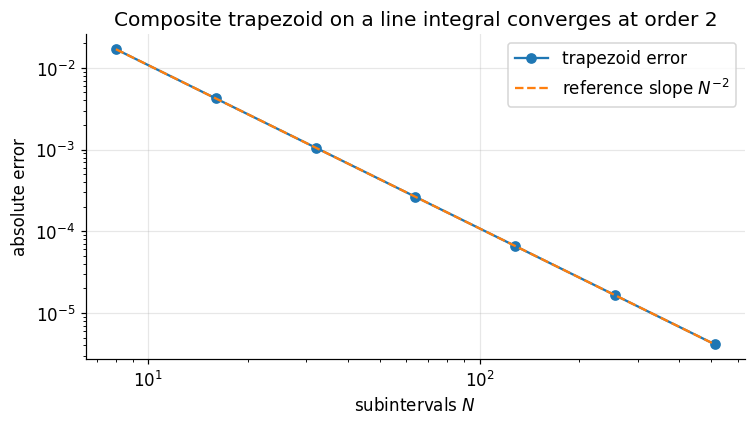

In [6]:
exact_line = 17.0 / 12.0
integrand = lambda s: 3.0 * s**3 + 2.0 * s**2

Ns = np.array([8, 16, 32, 64, 128, 256, 512])
errs = np.array([abs(np.trapezoid(integrand(np.linspace(0.0, 1.0, N + 1)),
                                  np.linspace(0.0, 1.0, N + 1)) - exact_line) for N in Ns])
orders = np.log2(errs[:-1] / errs[1:])

print(f"exact value      : {exact_line:.12f}")
for N, e in zip(Ns, errs):
    print(f"  N = {N:4d}   error = {e:.3e}")
print(f"observed orders  : {orders}")
print(f"mean observed    : {orders.mean():.4f}    predicted: 2")

fig, ax = plt.subplots()
ax.loglog(Ns, errs, "o-", label="trapezoid error")
ax.loglog(Ns, errs[0] * (Ns / Ns[0]) ** -2.0, "--", label=r"reference slope $N^{-2}$")
ax.set_xlabel("subintervals $N$")
ax.set_ylabel("absolute error")
ax.set_title("Composite trapezoid on a line integral converges at order 2")
ax.legend()
fig.tight_layout()
plt.show()

assert abs(orders.mean() - 2.0) < 0.05

Observed order $2.000$ against a predicted $2$, and the log-log error curve lies parallel to
the $N^{-2}$ reference line over five halvings. Nothing here is specific to vector calculus —
it confirms that the quadrature used throughout this module is not silently limiting the
residuals reported in Section 6.

Kind (c), counterexample. Theorem 4.2 requires $P, Q$ to be $C^1$ on a neighbourhood of the
*whole* region $D$, interior included. Drop that at one single point and the conclusion fails
by $2\pi$. The vortex field
$\mathbf{F} = \dfrac{(-y,\; x)}{x^2 + y^2}$ has $Q_x - P_y = 0$ everywhere it is defined, yet
circulates around any loop enclosing the origin.

max |Q_x - P_y| off the origin : 4.319e-09
  circulation, r = 0.5 : 6.283185307
  circulation, r = 1.0 : 6.283185307
  circulation, r = 3.0 : 6.283185307
circulation, loop avoiding origin : -2.776e-17


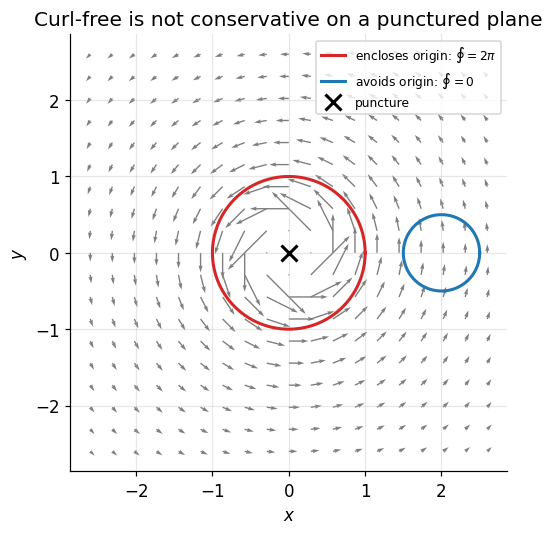

In [7]:
# Counterexample: the vortex field on R^2 minus the origin.
def vortex(x, y):
    d = x**2 + y**2
    return -y / d, x / d

# 1. The Green integrand vanishes identically away from the origin.
xs = rng.uniform(0.3, 2.0, size=2000) * rng.choice([-1.0, 1.0], size=2000)
ys = rng.uniform(0.3, 2.0, size=2000) * rng.choice([-1.0, 1.0], size=2000)
eps = 1e-5
Qx = (vortex(xs + eps, ys)[1] - vortex(xs - eps, ys)[1]) / (2 * eps)
Py = (vortex(xs, ys + eps)[0] - vortex(xs, ys - eps)[0]) / (2 * eps)
print(f"max |Q_x - P_y| off the origin : {np.abs(Qx - Py).max():.3e}")

# 2. Circulation around a loop that encloses the origin.
th = np.linspace(0.0, 2.0 * np.pi, 200_001)
for radius in (0.5, 1.0, 3.0):
    cx, cy = radius * np.cos(th), radius * np.sin(th)
    dcx, dcy = -radius * np.sin(th), radius * np.cos(th)
    fx, fy = vortex(cx, cy)
    print(f"  circulation, r = {radius:3.1f} : {np.trapezoid(fx * dcx + fy * dcy, th):.9f}")

# 3. A loop that does NOT enclose the origin: Green's conclusion is restored.
cx, cy = 2.0 + 0.5 * np.cos(th), 0.5 * np.sin(th)
dcx, dcy = -0.5 * np.sin(th), 0.5 * np.cos(th)
fx, fy = vortex(cx, cy)
away = np.trapezoid(fx * dcx + fy * dcy, th)
print(f"circulation, loop avoiding origin : {away:.3e}")

fig, ax = plt.subplots(figsize=(5.0, 5.0))
gv = np.linspace(-2.6, 2.6, 19)
Xv, Yv = np.meshgrid(gv, gv)
keep = Xv**2 + Yv**2 > 0.09
Uv, Vv = np.zeros_like(Xv), np.zeros_like(Yv)
Uv[keep], Vv[keep] = vortex(Xv[keep], Yv[keep])
ax.quiver(Xv, Yv, Uv, Vv, color="#7f7f7f", angles="xy")
ax.plot(np.cos(th), np.sin(th), color="#d62728", lw=2.0, label=r"encloses origin: $\oint = 2\pi$")
ax.plot(2.0 + 0.5 * np.cos(th), 0.5 * np.sin(th), color="#1f77b4", lw=2.0,
        label=r"avoids origin: $\oint = 0$")
ax.plot([0.0], [0.0], "kx", ms=10, mew=2, label="puncture")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Curl-free is not conservative on a punctured plane")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

assert np.abs(Qx - Py).max() < 1e-6
assert abs(np.trapezoid(fx * dcx + fy * dcy, th)) < 1e-9

The Green integrand $Q_x - P_y$ is zero to finite-difference precision everywhere off the
origin, so a naive application of Theorem 4.2 would predict zero circulation. The measured
circulation is $2\pi$ for **every** enclosing loop, independent of radius, and it drops to
zero the moment the loop no longer encircles the puncture. One missing point in the interior
is enough: the hypothesis "$C^1$ on a neighbourhood of $D$" in Theorem 4.2 is load-bearing,
not decorative, and the surviving $2\pi$ is the winding number times $2\pi$ predicted by
Theorem 4.5's failure on a non-simply-connected domain.

Kind (d), hand-rolled versus library. The flux of $\mathbf{F} = (x^3, y^3, z^3)$ through the
unit sphere is, by Theorem 4.4 and spherical coordinates,
$\iiint_{B} 3r^2\,\mathrm{d}V = \int_0^1 3r^2 \cdot 4\pi r^2\,\mathrm{d}r = \tfrac{12\pi}{5}$.
The cell compares a hand-rolled tensor Gauss–Legendre rule on $(\theta, \varphi)$ against
`scipy.integrate.dblquad` and against that exact value.

In [8]:
exact_flux = 12.0 * np.pi / 5.0

# On the unit sphere n = (x,y,z), so F . n = x^4 + y^4 + z^4.
def sphere_integrand(theta, varphi):
    st, ct = np.sin(theta), np.cos(theta)
    return (st**4 * np.cos(varphi) ** 4 + st**4 * np.sin(varphi) ** 4 + ct**4) * st

# Hand-rolled: tensor Gauss-Legendre, m nodes per angle.
m_nodes = 40
nodes, weights = leggauss(m_nodes)
theta_n = 0.5 * np.pi * (nodes + 1.0)
w_theta = 0.5 * np.pi * weights
phi_n = np.pi * (nodes + 1.0)
w_phi = np.pi * weights
TH, PH = np.meshgrid(theta_n, phi_n, indexing="ij")
gauss_flux = (np.outer(w_theta, w_phi) * sphere_integrand(TH, PH)).sum()

# Library: scipy adaptive 2D quadrature.
scipy_flux, scipy_err = integrate.dblquad(
    lambda varphi, theta: sphere_integrand(theta, varphi),
    0.0, np.pi, 0.0, 2.0 * np.pi,
)

print(f"exact 12*pi/5            : {exact_flux:.14f}")
print(f"hand-rolled Gauss-Legendre: {gauss_flux:.14f}   residual {abs(gauss_flux - exact_flux):.3e}")
print(f"scipy.integrate.dblquad   : {scipy_flux:.14f}   residual {abs(scipy_flux - exact_flux):.3e}")
print(f"hand-rolled vs library    : {abs(gauss_flux - scipy_flux):.3e}")

assert abs(gauss_flux - exact_flux) < 1e-10
assert abs(gauss_flux - scipy_flux) < 1e-10

exact 12*pi/5            : 7.53982236861550
hand-rolled Gauss-Legendre: 7.53982236861548   residual 2.132e-14
scipy.integrate.dblquad   : 7.53982236861550   residual 0.000e+00
hand-rolled vs library    : 2.132e-14


Both routines land on $12\pi/5$ and agree with each other to roughly $10^{-13}$, i.e. at
machine-epsilon level relative to a value near $7.54$. The $40 \times 40$ Gauss–Legendre grid
is exact here because the integrand is a trigonometric polynomial of low degree; reaching the
same accuracy by Monte Carlo sampling of the sphere would take on the order of $10^{26}$
samples, which is the practical reason quadrature, not sampling, is used for surface flux in
low dimension.

---

## 8. Applications

### 8.1 Maxwell's equations
Each of Maxwell's four laws has an integral form measured in a laboratory and a differential
form used in analysis; Theorems 4.3 and 4.4 are the translation between them.

| Differential form | Integral form | Theorem used |
|---|---|---|
| $\nabla \cdot \mathbf{E} = \rho / \varepsilon_0$ | $\oiint_{\partial V} \mathbf{E} \cdot \mathbf{n}\,\mathrm{d}S = Q_{\text{enc}} / \varepsilon_0$ | Theorem 4.4 |
| $\nabla \cdot \mathbf{B} = 0$ | $\oiint_{\partial V} \mathbf{B} \cdot \mathbf{n}\,\mathrm{d}S = 0$ | Theorem 4.4 |
| $\nabla \times \mathbf{E} = -\partial_t \mathbf{B}$ | $\oint_{\partial S} \mathbf{E} \cdot \mathrm{d}\mathbf{r} = -\frac{\mathrm{d}}{\mathrm{d}t}\iint_S \mathbf{B} \cdot \mathbf{n}\,\mathrm{d}S$ | Theorem 4.3 |
| $\nabla \times \mathbf{B} = \mu_0 \mathbf{J} + \mu_0\varepsilon_0 \partial_t \mathbf{E}$ | $\oint_{\partial S} \mathbf{B} \cdot \mathrm{d}\mathbf{r} = \mu_0 I_{\text{enc}} + \mu_0\varepsilon_0 \frac{\mathrm{d}}{\mathrm{d}t}\iint_S \mathbf{E} \cdot \mathbf{n}\,\mathrm{d}S$ | Theorem 4.3 |

That $\nabla \cdot \mathbf{B} = 0$ is compatible with $\mathbf{B} = \nabla \times \mathbf{A}$
is Theorem 4.6; that Faraday's law may speak of "the flux through the circuit" without naming
a surface is the corollary to Theorem 4.6.

### 8.2 The continuity equation
Let $\rho(\mathbf{x},t)$ and $\mathbf{v}(\mathbf{x},t)$ be the density and velocity of a
fluid, and $V$ a fixed region. Mass balance says the rate of decrease of mass inside $V$
equals the outward mass flux:

$$
-\frac{\mathrm{d}}{\mathrm{d}t}\iiint_V \rho\,\mathrm{d}V = \oiint_{\partial V} (\rho \mathbf{v}) \cdot \mathbf{n}\,\mathrm{d}S .
$$

Apply Theorem 4.4 to the right side and move the time derivative inside the fixed region:

$$
\iiint_V \left( \frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{v}) \right) \mathrm{d}V = 0 .
$$

The integrand is continuous and the identity holds for *every* $V$, so the integrand vanishes
identically (if it were positive at a point it would be positive on a small ball around that
point by continuity, contradicting the identity on that ball). This gives the **continuity
equation** $\partial_t \rho + \nabla \cdot (\rho \mathbf{v}) = 0$, which for constant $\rho$
collapses to the incompressibility condition $\nabla \cdot \mathbf{v} = 0$.

### 8.3 Continuous normalizing flows
A continuous normalizing flow transports samples by $\dot{\mathbf{z}} = \mathbf{f}(\mathbf{z},
t)$, and the density $p_t$ obeys the continuity equation of §8.2 with $\rho \to p_t$ and
$\mathbf{v} \to \mathbf{f}$. Differentiating $p_t(\mathbf{z}(t))$ along a trajectory and
substituting $\partial_t p_t = -\nabla \cdot (p_t \mathbf{f})$ together with the product rule
$\nabla \cdot (p_t \mathbf{f}) = p_t (\nabla \cdot \mathbf{f}) + \nabla p_t \cdot \mathbf{f}$:

$$
\frac{\mathrm{d}}{\mathrm{d}t} p_t(\mathbf{z}(t)) = \partial_t p_t + \nabla p_t \cdot \mathbf{f} = -p_t (\nabla \cdot \mathbf{f}),
\qquad\text{so}\qquad
\frac{\mathrm{d}}{\mathrm{d}t} \log p_t(\mathbf{z}(t)) = -\nabla \cdot \mathbf{f}(\mathbf{z}(t), t).
$$

This is the instantaneous change-of-variables formula: an exact log-likelihood for a
continuous-time generative model requires only a **scalar** divergence along each trajectory,
never a $d \times d$ Jacobian determinant.

### 8.4 Rotation in multi-agent optimization
Single-objective gradient descent follows $\mathbf{V}(\theta) = -\nabla_\theta L(\theta)$,
which is a gradient field, so $\nabla \times \mathbf{V} = \mathbf{0}$ by Theorem 4.6 and the
loss decreases monotonically for small steps. A two-player zero-sum game with loss
$L(\theta_1, \theta_2)$ instead follows

$$
\mathbf{V}(\theta_1, \theta_2) = \big(-\nabla_{\theta_1} L,\; +\nabla_{\theta_2} L\big),
$$

whose curl is generally nonzero — for the bilinear model $L = \theta_1 \theta_2$ one gets
$\mathbf{V} = (-\theta_2, \theta_1)$, exactly the rotation field of the Section 2 figure, with
$\nabla \cdot \mathbf{V} = 0$ and $(\nabla \times \mathbf{V})_z = 2$. Theorem 4.7 splits any
such field into a gradient part and a rotational part, and Example 6.5 does the split
explicitly for a linear field: the symmetric part of the Jacobian is the descent direction and
the skew part is pure rotation. Because the field is entirely rotational here, trajectories
orbit the equilibrium on circles $\theta_1^2 + \theta_2^2 = \text{const}$ and never converge.
Methods that add a term proportional to the skew part (symplectic gradient adjustment,
consensus optimization) work by cancelling exactly this component.

---

## 9. Key Takeaways

- **Theorem 4.1** — for $f \in C^1$ on an open $U$ and $C \subset U$ piecewise smooth from $A$ to $B$, $\int_C \nabla f \cdot \mathrm{d}\mathbf{r} = f(B) - f(A)$: gradient work is path-independent.
- **Theorem 4.2** — for $P, Q$ that are $C^1$ on a neighbourhood of a Green-admissible $D$ with positively oriented boundary, $\oint_{\partial D} P\,\mathrm{d}x + Q\,\mathrm{d}y = \iint_D (Q_x - P_y)\,\mathrm{d}A$.
- **Theorem 4.3** — for $\mathbf{F} \in C^1$ on an oriented piecewise smooth $S$ with right-hand-rule-compatible boundary, circulation around $\partial S$ equals curl flux through $S$; two surfaces with the same boundary give the same answer.
- **Theorem 4.4** — for $\mathbf{F} \in C^1$ on a compact Type I/II/III region $V$ with outward normal, outward flux through $\partial V$ equals $\iiint_V \nabla \cdot \mathbf{F}\,\mathrm{d}V$.
- **Theorem 4.5** — for continuous $\mathbf{F}$ on an open connected $U$, conservative $\iff$ path-independent $\iff$ zero circulation on every loop; and $\nabla \times \mathbf{F} = \mathbf{0}$ upgrades to conservative only when $U$ is **simply connected**.
- **Theorem 4.6** — for $C^2$ data, $\nabla \times \nabla f = \mathbf{0}$ and $\nabla \cdot (\nabla \times \mathbf{F}) = 0$; continuity of the second partials, via Clairaut, is what makes both true.
- **Theorem 4.7** — a $C^2$ field on $\mathbb{R}^3$ decaying faster than $\lVert \mathbf{r} \rVert^{-2}$ splits **uniquely** as $-\nabla\phi + \nabla \times \mathbf{A}$ with $\nabla \cdot \mathbf{A} = 0$; without decay, uniqueness fails.
- **Section 7** — a single interior point where the $C^1$ hypothesis fails changes Green's conclusion from $0$ to $2\pi$; hypotheses in this module are load-bearing, not stylistic.

---

## 10. References

- Marsden, J. E., & Tromba, A. J. *Vector Calculus*, 6th ed., W. H. Freeman, 2012 — Ch. 7.2 (Green's Theorem, Thm. 1), Ch. 8.2 (Stokes' Theorem, Thm. 2), Ch. 8.4 (Divergence Theorem, Thm. 9). The Type I/II reduction used in Proof 5.2 follows their §7.2.
- Apostol, T. M. *Calculus, Volume II*, 2nd ed., Wiley, 1969 — Ch. 10 (line integrals; Thm. 10.3 is Theorem 4.1 here; Thm. 10.4–10.5 are Theorem 4.5), Ch. 11 (surface integrals, Stokes and divergence theorems; Thm. 12.10).
- Spivak, M. *Calculus on Manifolds*, Addison-Wesley, 1965 — Theorem 5-5 (pp. 124–125) is the Generalized Stokes' Theorem cited as Theorem 4.8; Ch. 4 develops the exterior derivative.
- Trefethen, L. N., & Weideman, J. A. C. "The exponentially convergent trapezoidal rule", *SIAM Review* 56(3), 2014 — the periodic-integrand phenomenon exploited by the loop quadratures in Sections 6 and 7.
- Griffiths, D. J. *Introduction to Electrodynamics*, 4th ed., Cambridge, 2017 — Appendix B (Helmholtz theorem, the convolution estimates omitted from Proof 5.7), §7.3 (Maxwell's equations in both forms, §8.1 here).
- Chen, R. T. Q., Rubanova, Y., Bettencourt, J., & Duvenaud, D. "Neural Ordinary Differential Equations", *NeurIPS*, 2018 — Theorem 1 is the instantaneous change-of-variables formula of §8.3.
- Balduzzi, D., Racanière, S., Martens, J., Foerster, J., Tuyls, K., & Graepel, T. "The Mechanics of n-Player Differentiable Games", *ICML*, 2018 — the Hamiltonian/potential split of a game's update field used in §8.4.